
================ METRIC (equatorial Kerr) =================
g_tt(r) = 
2⋅M - r
───────
   r   

LaTeX[g_tt] =
\frac{2 M - r}{r}


u^t(r;E,L) =
       2      2        3          
2⋅E⋅M⋅a  + E⋅a ⋅r + E⋅r  - 2⋅L⋅M⋅a
──────────────────────────────────
         ⎛          2    2⎞       
       r⋅⎝-2⋅M⋅r + a  + r ⎠       

LaTeX[u^t] =
\frac{2 E M a^{2} + E a^{2} r + E r^{3} - 2 L M a}{r \left(- 2 M r + a^{2} + r^{2}\right)}


u^phi(r;E,L) =
2⋅E⋅M⋅a - 2⋅L⋅M + L⋅r
─────────────────────
  ⎛          2    2⎞ 
r⋅⎝-2⋅M⋅r + a  + r ⎠ 

LaTeX[u^phi] =
\frac{2 E M a - 2 L M + L r}{r \left(- 2 M r + a^{2} + r^{2}\right)}

================ V_eff(r;E,L) ============================
Defined through:
  g_tt (u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2 + g_rr (u^r)^2 = -mu^2
  ⇒ V_eff = g_tt (u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2

V_eff(r;E,L) =
     2    2    2  2      2  3                  2      2  
- 2⋅E ⋅M⋅a  - E ⋅a ⋅r - E ⋅r  + 4⋅E⋅L⋅M⋅a - 2⋅L ⋅M + L ⋅r
──────────────────────────────────

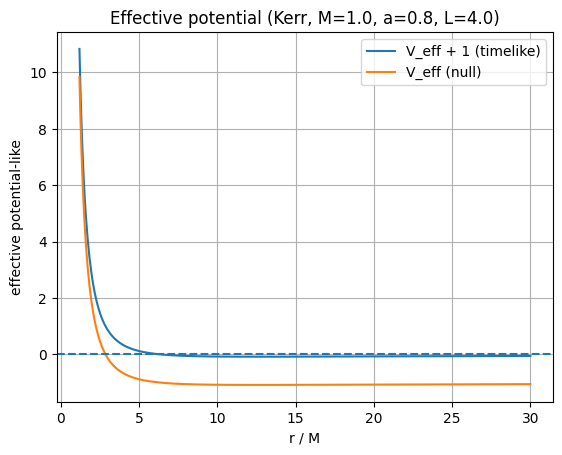

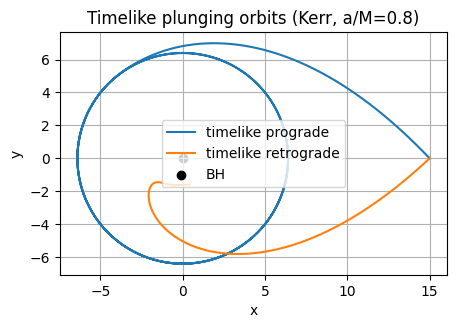

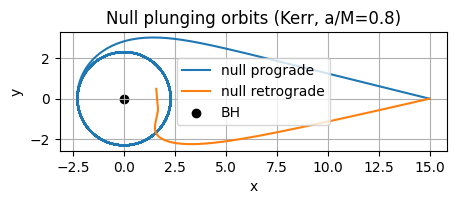

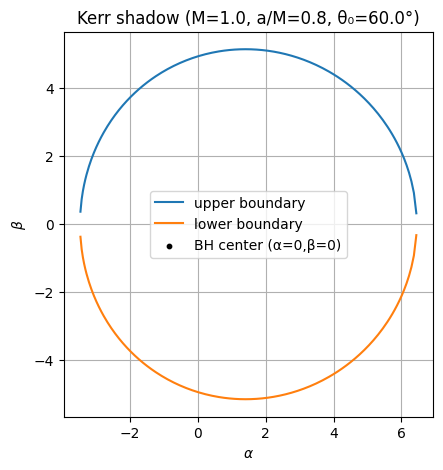

In [ ]:
# ============================================================
# General equatorial geodesics + Kerr shadow (Wei+Mann 2019)
# ============================================================
#
# - User supplies equatorial metric components:
#       g_tt(r), g_rr(r), g_thth(r), g_phph(r), g_tphi(r)
#   (we use Kerr in Boyer–Lindquist as the example)
#
# - From Killing vectors:
#       E = -u_t  (energy)
#       L =  u_phi (azimuthal angular momentum)
#
# - Symbolically derive:
#       u^t(r;E,L), u^phi(r;E,L)
#       V_eff(r;E,L)
#       R(r;E,L,mu^2) = (dr/dλ)^2  (general, timelike, null)
#
# - Print both pretty (pprint) AND LaTeX versions of:
#       V_eff, R_timelike, R_null
#
# - Numerically integrate equatorial geodesics (Kerr example):
#       * timelike plunges (prograde & retrograde)
#       * null plunges (prograde & retrograde)
#
# - Kerr ISCO radii (analytic)
#
# - Kerr shadow boundary (tilted / deformed) using
#   Wei et al. arXiv:1904.07710 (their eqs. (2.11)–(2.14)):
#
#       α = -ξ csc θ0
#       β = ±sqrt(η + a^2 cos^2 θ0 - ξ^2 cot^2 θ0)
#
#   with ξ(r0), η(r0) from eqs. (2.13)–(2.14).
#
#   This gives a properly deformed Kerr shadow for arbitrary spin a
#   and observer inclination θ0.
#
# ------------------------------------------------------------

import numpy as np
import sympy as sp
from sympy import nsolve, latex
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# 1. Symbols and parameters
# ============================================================

# Coordinates (equatorial): t, r, phi
t_sym, r_sym, phi_sym = sp.symbols('t r phi', real=True)
E_sym, L_sym = sp.symbols('E L', real=True)     # conserved energy, angular momentum
mu2_sym = sp.symbols('mu2', real=True)         # +1 timelike, 0 null

# Parameters for Kerr
M_sym, a_sym = sp.symbols('M a', real=True, positive=True)

# ============================================================
# 2. Metric components in equatorial plane
#    USER-EDITABLE BLOCK (Kerr here)
# ============================================================

def get_metric_components_equatorial():
    """
    Return symbolic metric components in the equatorial plane θ=π/2:
        g_tt(r), g_rr(r), g_thth(r), g_phph(r), g_tphi(r)

    Kerr in Boyer–Lindquist:
      Δ = r^2 - 2 M r + a^2
      Σ = r^2  (at θ = π/2)

      g_tt   = -(1 - 2 M r / Σ)
      g_rr   =  Σ / Δ
      g_thth =  Σ
      g_tphi = - 2 M a r / Σ
      g_phph = (r^2 + a^2 + 2 M a^2 r / Σ)
    """
    r = r_sym
    M, a = M_sym, a_sym

    Delta = r**2 - 2*M*r + a**2
    Sigma = r**2          # θ = π/2

    g_tt   = -(1 - 2*M*r/Sigma)
    g_rr   = Sigma/Delta
    g_thth = Sigma
    g_tphi = -2*M*a*r/Sigma
    g_phph = (r**2 + a**2 + 2*M*a**2*r/Sigma)

    return g_tt, g_rr, g_thth, g_phph, g_tphi


g_tt_expr, g_rr_expr, g_thth_expr, g_phph_expr, g_tphi_expr = get_metric_components_equatorial()

# ============================================================
# 3. Killing vectors → u^t, u^phi → V_eff → radial equation
# ============================================================

# Determinant of the (t, φ) 2x2 block
D_expr = -g_tt_expr*g_phph_expr + g_tphi_expr**2

# Solve E = -u_t, L = u_phi:
#   E = -g_tt u^t - g_tphi u^phi
#   L =  g_tphi u^t + g_phph u^phi
u_t_hat_expr   = (E_sym*g_phph_expr + L_sym*g_tphi_expr) / D_expr
u_phi_hat_expr = (-E_sym*g_tphi_expr - L_sym*g_tt_expr) / D_expr

# Effective potential term V_eff ≡ g_tt(u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2
V_eff_expr = sp.simplify(
    g_tt_expr*u_t_hat_expr**2 +
    2*g_tphi_expr*u_t_hat_expr*u_phi_hat_expr +
    g_phph_expr*u_phi_hat_expr**2
)

# Normalization:
#   g_tt (u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2 + g_rr (u^r)^2 = -mu^2
# ⇒ g_rr (u^r)^2 = -mu^2 - V_eff
# ⇒ R(r;E,L,mu^2) ≡ (dr/dλ)^2 = (u^r)^2 = [ -mu^2 - V_eff ] / g_rr
R_expr = sp.simplify((-mu2_sym - V_eff_expr) / g_rr_expr)

# Timelike / null specializations (symbolic)
R_timelike_expr = sp.simplify(R_expr.subs(mu2_sym, 1))  # mu^2 = +1
R_null_expr     = sp.simplify(R_expr.subs(mu2_sym, 0))  # mu^2 = 0

# ============================================================
# 3b. Numeric lambdified versions
# ============================================================

g_tt_num   = sp.lambdify((r_sym, M_sym, a_sym), g_tt_expr,   'numpy')
g_rr_num   = sp.lambdify((r_sym, M_sym, a_sym), g_rr_expr,   'numpy')
g_phph_num = sp.lambdify((r_sym, M_sym, a_sym), g_phph_expr, 'numpy')
g_tphi_num = sp.lambdify((r_sym, M_sym, a_sym), g_tphi_expr, 'numpy')

u_t_hat_num   = sp.lambdify((r_sym, E_sym, L_sym, M_sym, a_sym), u_t_hat_expr,   'numpy')
u_phi_hat_num = sp.lambdify((r_sym, E_sym, L_sym, M_sym, a_sym), u_phi_hat_expr, 'numpy')

R_timelike_num = sp.lambdify((r_sym, E_sym, L_sym, M_sym, a_sym),
                             R_timelike_expr, 'numpy')
R_null_num = sp.lambdify((r_sym, E_sym, L_sym, M_sym, a_sym),
                         R_null_expr, 'numpy')

V_eff_num = sp.lambdify((r_sym, E_sym, L_sym, M_sym, a_sym),
                        V_eff_expr, 'numpy')

# ============================================================
# 3c. Printing symbolic + LaTeX versions
# ============================================================

def print_symbolic_and_latex():
    print("\n================ METRIC (equatorial Kerr) =================")
    print("g_tt(r) = ")
    sp.pprint(sp.simplify(g_tt_expr))
    print("\nLaTeX[g_tt] =")
    print(latex(sp.simplify(g_tt_expr)))

    print("\n\nu^t(r;E,L) =")
    sp.pprint(sp.simplify(u_t_hat_expr))
    print("\nLaTeX[u^t] =")
    print(latex(sp.simplify(u_t_hat_expr)))

    print("\n\nu^phi(r;E,L) =")
    sp.pprint(sp.simplify(u_phi_hat_expr))
    print("\nLaTeX[u^phi] =")
    print(latex(sp.simplify(u_phi_hat_expr)))

    print("\n================ V_eff(r;E,L) ============================")
    print("Defined through:")
    print("  g_tt (u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2 + g_rr (u^r)^2 = -mu^2")
    print("  ⇒ V_eff = g_tt (u^t)^2 + 2 g_tphi u^t u^phi + g_phph (u^phi)^2")
    print("\nV_eff(r;E,L) =")
    sp.pprint(sp.simplify(V_eff_expr))
    print("\nLaTeX[V_eff] =")
    print(latex(sp.simplify(V_eff_expr)))

    print("\n================ RADIAL EQUATION (general) ===============")
    print("R(r;E,L,mu^2) = (dr/dλ)^2 = [ -mu^2 - V_eff(r;E,L) ] / g_rr(r)")
    print("\nR(r;E,L,mu^2) =")
    sp.pprint(sp.simplify(R_expr))
    print("\nLaTeX[R_general] =")
    print(latex(sp.simplify(R_expr)))

    print("\n================ TIMELIKE (mu^2 = +1) ====================")
    print("(dr/dλ)^2 = R_timelike(r;E,L)")
    print("\nR_timelike(r;E,L) =")
    sp.pprint(R_timelike_expr)
    print("\nLaTeX[R_timelike] =")
    print(latex(R_timelike_expr))

    print("\n================ NULL (mu^2 = 0) =========================")
    print("(dr/dλ)^2 = R_null(r;E,L)")
    print("\nR_null(r;E,L) =")
    sp.pprint(R_null_expr)
    print("\nLaTeX[R_null] =")
    print(latex(R_null_expr))
    print("\n=========================================================\n")


# ============================================================
# 4. ISCO radius for Kerr (analytic)
# ============================================================

def kerr_isco_radius(M, a, prograde=True):
    """
    ISCO radius r_ISCO for Kerr (equatorial).
    a is the spin parameter (|a| <= M).
    prograde=True → co-rotating, prograde=False → counter-rotating.
    """
    a_hat = a / M
    sign = +1 if prograde else -1

    Z1 = 1 + (1 - a_hat**2)**(1/3) * (
        (1 + a_hat)**(1/3) + (1 - a_hat)**(1/3)
    )
    Z2 = np.sqrt(3*a_hat**2 + Z1**2)
    r_isco = M * (3 + Z2 - sign * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2)))
    return r_isco

# ============================================================
# 5. Equatorial geodesic integration
# ============================================================

def geodesic_rhs_affine(lambda_, Y, E, L, M_val, a_val, mu2):
    """
    System:
        dt/dλ   = u^t(r;E,L)
        dr/dλ   = -sqrt(R(r;E,L,mu^2))  (infalling branch; zero if not allowed)
        dphi/dλ = u^phi(r;E,L)
    """
    t, r, phi = Y

    ut   = float(u_t_hat_num(r, E, L, M_val, a_val))
    uphi = float(u_phi_hat_num(r, E, L, M_val, a_val))

    if mu2 == 1:
        R_val = float(R_timelike_num(r, E, L, M_val, a_val))
    else:
        R_val = float(R_null_num(r, E, L, M_val, a_val))

    if R_val < 0:
        dr_dlam = 0.0
    else:
        dr_dlam = -np.sqrt(R_val)  # inward

    return [ut, dr_dlam, uphi]


def integrate_geodesic(E, L, r0, phi0, M_val, a_val, mu2,
                       lam_max=100.0, n_steps=2000):
    """
    Integrate a timelike (mu2=1) or null (mu2=0) equatorial geodesic.
    """
    lam_span = (0.0, lam_max)
    Y0 = [0.0, r0, phi0]

    sol = solve_ivp(
        geodesic_rhs_affine,
        lam_span,
        Y0,
        t_eval=np.linspace(lam_span[0], lam_span[1], n_steps),
        args=(E, L, M_val, a_val, mu2),
        rtol=1e-8,
        atol=1e-10
    )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

# ============================================================
# 6. Plot helpers for orbits
# ============================================================

def plot_orbit(r_arr, phi_arr, label=None):
    x = r_arr * np.cos(phi_arr)
    y = r_arr * np.sin(phi_arr)
    plt.plot(x, y, label=label)


def plot_orbits_prograde_retrograde(M_val=1.0, a_val=0.5,
                                    E_timelike=1.0, L_mag_timelike=4.0,
                                    E_null=1.0, L_mag_null=3.5,
                                    r_start=15.0, lam_max=200.0):
    """
    Plot timelike and null plunging orbits for both prograde and retrograde
    (L>0 and L<0).
    """
    phi_start = 0.0

    # -------- timelike: prograde (L>0) --------
    lam_p, t_p, r_p, phi_p = integrate_geodesic(
        E_timelike, +L_mag_timelike, r_start, phi_start,
        M_val, a_val, mu2=1,
        lam_max=lam_max, n_steps=4000
    )

    # -------- timelike: retrograde (L<0) ------
    lam_r, t_r, r_r, phi_r = integrate_geodesic(
        E_timelike, -L_mag_timelike, r_start, phi_start,
        M_val, a_val, mu2=1,
        lam_max=lam_max, n_steps=4000
    )

    plt.figure(figsize=(5, 5))
    plot_orbit(r_p, phi_p, label="timelike prograde")
    plot_orbit(r_r, phi_r, label="timelike retrograde")
    plt.scatter([0], [0], marker='o', color='k', label='BH')
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Timelike plunging orbits (Kerr, a/M={a_val})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # -------- null: prograde (L>0) ------------
    lam_np, t_np, r_np, phi_np = integrate_geodesic(
        E_null, +L_mag_null, r_start, phi_start,
        M_val, a_val, mu2=0,
        lam_max=lam_max, n_steps=4000
    )

    # -------- null: retrograde (L<0) ----------
    lam_nr, t_nr, r_nr, phi_nr = integrate_geodesic(
        E_null, -L_mag_null, r_start, phi_start,
        M_val, a_val, mu2=0,
        lam_max=lam_max, n_steps=4000
    )

    plt.figure(figsize=(5, 5))
    plot_orbit(r_np, phi_np, label="null prograde")
    plot_orbit(r_nr, phi_nr, label="null retrograde")
    plt.scatter([0], [0], marker='o', color='k', label='BH')
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Null plunging orbits (Kerr, a/M={a_val})")
    plt.grid(True)
    plt.legend()
    plt.show()

# ============================================================
# 7. Effective potential plots
# ============================================================

def plot_effective_potentials(M_val=1.0, a_val=0.5, L_val=4.0,
                              r_min=1.2, r_max=30.0, n=500):
    r_vals = np.linspace(r_min, r_max, n)
    E_plot = 1.0

    V_timelike_vals = V_eff_num(r_vals, E_plot, L_val, M_val, a_val) + 1.0  # μ^2=1
    V_null_vals     = V_eff_num(r_vals, E_plot, L_val, M_val, a_val)       # μ^2=0

    plt.figure()
    plt.plot(r_vals, V_timelike_vals, label=r'V_eff + 1 (timelike)')
    plt.plot(r_vals, V_null_vals,     label=r'V_eff (null)')
    plt.axhline(0, linestyle='--')
    plt.xlabel("r / M")
    plt.ylabel("effective potential-like")
    plt.title(f"Effective potential (Kerr, M={M_val}, a={a_val}, L={L_val})")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# 8. Kerr shadow boundary (tilted/deformed)
#    Using Wei et al. (1904.07710) eqs (2.11)–(2.14)
# ============================================================

def kerr_shadow_boundary(M_val=1.0, a_val=0.5, theta0=np.pi/3,
                         r_max=20.0, n_samples=2000):
    """
    Compute the Kerr shadow boundary (α, β) for given spin a and
    inclination θ0 using
        α = -ξ csc θ0
        β = ±sqrt(η + a^2 cos^2 θ0 - ξ^2 cot^2 θ0)
    with
        ξ(r0), η(r0) from eqs (2.13)-(2.14) of Wei+Mann 2019.

    Returns:
        alpha_plus, beta_plus, alpha_minus, beta_minus
    where "plus" and "minus" correspond to β >= 0 and β <= 0 branches.
    """

    M = M_val
    a = a_val
    th0 = theta0

    # Outer horizon r_+ = M + sqrt(M^2 - a^2)
    r_plus = M + np.sqrt(M**2 - a**2)
    r_min = r_plus + 1e-3

    r0_vals = np.linspace(r_min, r_max, n_samples)

    # ξ and η from eqs. (2.13)-(2.14)
    r0 = r0_vals
    xi  = ((3*M - r0)*r0**2 - a**2*(M + r0)) / (a*(r0 - M))
    eta = (r0**3 * (4*a**2*M - r0*(3*M - r0)**2)) / (a**2 * (r0 - M)**2)

    sin_th0 = np.sin(th0)
    cos_th0 = np.cos(th0)
    cot_th0 = cos_th0 / sin_th0

    disc = eta + a**2 * cos_th0**2 - xi**2 * cot_th0**2

    mask = disc >= 0
    xi = xi[mask]
    disc = disc[mask]
    r0 = r0[mask]

    alpha = -xi / sin_th0
    beta  = np.sqrt(disc)

    alpha_plus  = alpha
    beta_plus   = beta
    alpha_minus = alpha
    beta_minus  = -beta

    return alpha_plus, beta_plus, alpha_minus, beta_minus


def plot_kerr_shadow(M_val=1.0, a_val=0.95, theta0=np.pi/3):
    """
    Plot tilted / deformed Kerr shadow in (α, β) celestial coordinates
    for a given spin and inclination.
    """
    a_p, b_p, a_m, b_m = kerr_shadow_boundary(M_val, a_val, theta0)

    plt.figure(figsize=(5, 5))
    plt.plot(a_p, b_p,  label="upper boundary")
    plt.plot(a_m, b_m,  label="lower boundary")
    plt.scatter([0], [0], color='k', s=10, label='BH center (α=0,β=0)')

    plt.gca().set_aspect('equal', 'box')
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$\beta$")
    deg = theta0 * 180.0 / np.pi
    plt.title(f"Kerr shadow (M={M_val}, a/M={a_val}, θ₀={deg:.1f}°)")
    plt.grid(True)
    plt.legend()
    plt.show()

# ============================================================
# 9. Main: run all pieces
# ============================================================

if __name__ == "__main__":
    # Parameters
    M_val = 1.0
    a_val = 0.8   # choose a fairly high spin to see deformation

    # 1) Print symbolic equations and LaTeX versions
    print_symbolic_and_latex()

    # 2) ISCO radii (prograde and retrograde)
    r_isco_pro = kerr_isco_radius(M_val, a_val, prograde=True)
    r_isco_ret = kerr_isco_radius(M_val, a_val, prograde=False)
    print(f"ISCO (prograde)   r_ISCO ≈ {r_isco_pro:.6f}")
    print(f"ISCO (retrograde) r_ISCO ≈ {r_isco_ret:.6f}")

    # 3) Effective potential plots (equatorial)
    plot_effective_potentials(M_val=M_val, a_val=a_val, L_val=4.0,
                              r_min=1.2, r_max=30.0)

    # 4) Prograde & retrograde orbits (timelike + null)
    plot_orbits_prograde_retrograde(
        M_val=M_val,
        a_val=a_val,
        E_timelike=1.0,
        L_mag_timelike=4.0,
        E_null=1.0,
        L_mag_null=3.5,
        r_start=15.0,
        lam_max=200.0
    )

    # 5) Deformed / tilted Kerr shadow (using Wei+Mann formula)
    #    You can change θ0 to see tilt / asymmetry: e.g. θ0 = π/2, π/3, π/6 ...
    theta0 = np.pi/3   # 60 degrees inclination
    plot_kerr_shadow(M_val=M_val, a_val=a_val, theta0=theta0)
